In [1]:
# config + imports
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

CACHE_DIR   = Path.home() / 'vambersky_t/Data/exploration/cache'
FIG_DIR     = Path.home() / 'vambersky_t/Data/exploration/figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED  = 42
N_PCA        = 50   # components before LDA
TEST_SIZE    = 0.2

In [2]:
# load per-peak mean-pool vectors and TF labels from cache
X_parts, y_parts, file_parts = [], [], []

for npz_path in sorted(CACHE_DIR.rglob('*.derived.npz')):
    tf = npz_path.parent.name
    if tf == 'RANDOM':
        continue
    d = np.load(npz_path, allow_pickle=False)
    n = len(d['mean_pool'])
    X_parts.append(d['mean_pool'].astype(np.float32))
    y_parts.append(np.full(n, tf))
    file_parts.append(np.full(n, npz_path.stem))
    print(f'{npz_path.stem:50s}  n={n}')

X     = np.concatenate(X_parts, axis=0)   # (n_peaks, 4096)
y     = np.concatenate(y_parts, axis=0)   # TF label per peak
files = np.concatenate(file_parts, axis=0)

print(f'\nTotal  {X.shape}')
for tf, count in zip(*np.unique(y, return_counts=True)):
    print(f'  {tf:10s}  {count}')

ENCFF017XLW__CTCF__GM12878.derived                  n=9922
ENCFF692RPA__CTCF__H1.derived                       n=9901
ENCFF769AUF__CTCF__K562.derived                     n=9883
ENCFF149BIS__MYC__MCF-7.derived                     n=8175
ENCFF700CXD__MYC__H1.derived                        n=4936
ENCFF765CKK__MYC__GM12878.derived                   n=2203
ENCFF185DGL__SPI1__K562.derived                     n=9897
ENCFF198SPL__SPI1__GM12878.derived                  n=9919
ENCFF881ARS__SPI1__GM12878.derived                  n=9932

Total  (74768, 4096)
  CTCF        29706
  MYC         15314
  SPI1        29748


In [3]:
# GC baseline: per-peak mean GC from cache
gc_parts = []
for npz_path in sorted(CACHE_DIR.rglob('*.derived.npz')):
    tf = npz_path.parent.name
    if tf == 'RANDOM':
        continue
    d = np.load(npz_path, allow_pickle=False)
    gc_parts.append(d['gc'].mean(axis=1).astype(np.float32))  # (n_peaks,)

gc = np.concatenate(gc_parts, axis=0).reshape(-1, 1)  # (n_peaks, 1)
print(f'GC array: {gc.shape}  mean={gc.mean():.3f}  std={gc.std():.3f}')

GC array: (74768, 1)  mean=0.436  std=0.063


In [4]:
# stratified train/test split — same split used for both embedding LDA and GC baseline
le = LabelEncoder()
y_enc = le.fit_transform(y)

sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_SEED)
train_idx, test_idx = next(sss.split(X, y_enc))

X_train, X_test   = X[train_idx], X[test_idx]
gc_train, gc_test = gc[train_idx], gc[test_idx]
y_train, y_test   = y_enc[train_idx], y_enc[test_idx]

print(f'Train {X_train.shape}  Test {X_test.shape}')

Train (59814, 4096)  Test (14954, 4096)


In [5]:
# PCA compression — fit on train, apply to train+test
pca = PCA(n_components=N_PCA, random_state=RANDOM_SEED)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

print(f'Variance explained by {N_PCA} PCs: {pca.explained_variance_ratio_.sum():.3f}')

Variance explained by 50 PCs: 1.000


In [6]:
# LDA on PCA-compressed embeddings
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_pca, y_train)

y_pred = lda.predict(X_test_pca)
acc_emb = accuracy_score(y_test, y_pred)
cm_emb  = confusion_matrix(y_test, y_pred)

print(f'Embedding LDA accuracy: {acc_emb:.4f}')
print(f'Chance level:           {1/len(le.classes_):.4f}')

Embedding LDA accuracy: 0.4120
Chance level:           0.3333


In [7]:
# GC baseline LDA
lda_gc = LinearDiscriminantAnalysis()
lda_gc.fit(gc_train, y_train)

y_pred_gc = lda_gc.predict(gc_test)
acc_gc    = accuracy_score(y_test, y_pred_gc)
cm_gc     = confusion_matrix(y_test, y_pred_gc)

print(f'GC baseline LDA accuracy: {acc_gc:.4f}')
print(f'Embedding LDA accuracy:   {acc_emb:.4f}')
print(f'Delta:                    {acc_emb - acc_gc:+.4f}')

GC baseline LDA accuracy: 0.4040
Embedding LDA accuracy:   0.4120
Delta:                    +0.0080


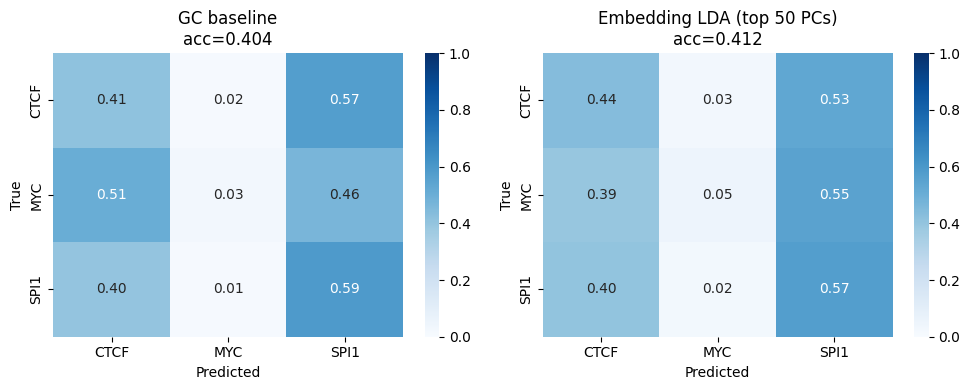

In [8]:
# confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels = le.classes_

for ax, cm, title in zip(
    axes,
    [cm_gc, cm_emb],
    ['GC baseline', f'Embedding LDA (top {N_PCA} PCs)']
):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', xticklabels=labels,
                yticklabels=labels, vmin=0, vmax=1, ax=ax, cmap='Blues')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{title}\nacc={cm.diagonal().sum()/cm.sum():.3f}')

fig.tight_layout()
fig.savefig(FIG_DIR / 'lda_confusion_matrices.svg', bbox_inches='tight')
fig.savefig(FIG_DIR / 'lda_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

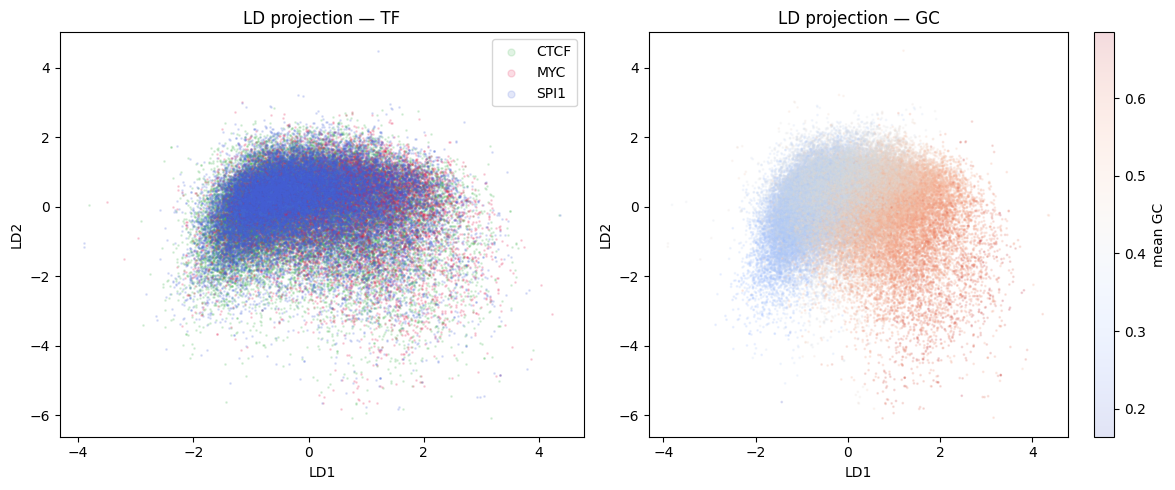

In [9]:
# LD1/LD2 projection — all peaks coloured by TF
X_all_pca = pca.transform(X)
X_ld      = lda.transform(X_all_pca)   # (n_peaks, 2)
gc_mean   = gc.ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
palette   = {'MYC': '#e6194b', 'CTCF': '#3cb44b', 'SPI1': '#4363d8'}

# colour by TF
ax = axes[0]
for tf in le.classes_:
    mask = y == tf
    ax.scatter(X_ld[mask, 0], X_ld[mask, 1], s=1, alpha=0.15,
               color=palette[tf], label=tf, rasterized=True)
ax.set_xlabel('LD1')
ax.set_ylabel('LD2')
ax.set_title('LD projection — TF')
ax.legend(markerscale=5)

# colour by GC
ax = axes[1]
sc = ax.scatter(X_ld[:, 0], X_ld[:, 1], s=1, alpha=0.15,
                c=gc_mean, cmap='coolwarm', rasterized=True)
plt.colorbar(sc, ax=ax, label='mean GC')
ax.set_xlabel('LD1')
ax.set_ylabel('LD2')
ax.set_title('LD projection — GC')

fig.tight_layout()
fig.savefig(FIG_DIR / 'lda_ld_projection.svg', bbox_inches='tight')
fig.savefig(FIG_DIR / 'lda_ld_projection.png', dpi=150, bbox_inches='tight')
plt.show()

n_pca=  10  acc=0.4081
n_pca=  20  acc=0.4127
n_pca=  50  acc=0.4120
n_pca= 100  acc=0.4138
n_pca= 200  acc=0.4127


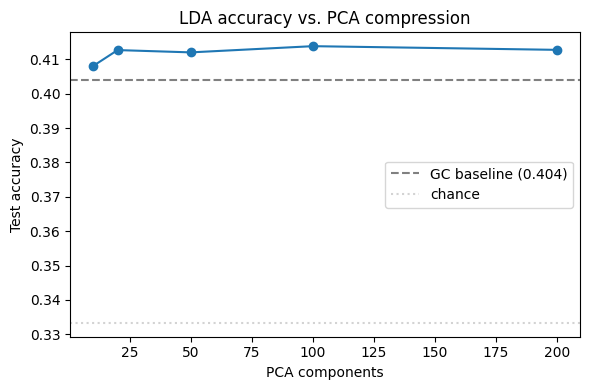

In [10]:
# sensitivity to N_PCA — refit LDA across a range of component counts
n_components = [10, 20, 50, 100, 200]
accs = []

for n in n_components:
    pca_n = PCA(n_components=n, random_state=RANDOM_SEED)
    Xtr = pca_n.fit_transform(X_train)
    Xte = pca_n.transform(X_test)
    lda_n = LinearDiscriminantAnalysis()
    lda_n.fit(Xtr, y_train)
    accs.append(accuracy_score(y_test, lda_n.predict(Xte)))
    print(f'n_pca={n:4d}  acc={accs[-1]:.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(n_components, accs, marker='o')
ax.axhline(acc_gc, color='grey', linestyle='--', label=f'GC baseline ({acc_gc:.3f})')
ax.axhline(1/len(le.classes_), color='lightgrey', linestyle=':', label='chance')
ax.set_xlabel('PCA components')
ax.set_ylabel('Test accuracy')
ax.set_title('LDA accuracy vs. PCA compression')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'lda_pca_sensitivity.svg', bbox_inches='tight')
fig.savefig(FIG_DIR / 'lda_pca_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()